In [1]:
import requests

url = (
    "https://archive-api.open-meteo.com/v1/archive"
    "?latitude=-6.9175"
    "&longitude=107.6191"
    "&start_date=2010-01-01"
    "&end_date=2026-05-31"
    "&daily=precipitation_sum"
    "&timezone=Asia%2FJakarta"
)

response = requests.get(url)
data = response.json()

print(data['daily']['time'][:5])
print(data['daily']['precipitation_sum'][:5])

['2010-01-01', '2010-01-02', '2010-01-03', '2010-01-04', '2010-01-05']
[24.2, 18.3, 19.6, 23.8, 15.5]


In [2]:
import pandas as pd

df = pd.DataFrame({
    'date': data['daily']['time'],
    'precipitation_mm': data['daily']['precipitation_sum']
})

df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

print(df.shape)
print(df.head())
print(df.tail())
print(df.isnull().sum())

(5995, 1)
            precipitation_mm
date                        
2010-01-01              24.2
2010-01-02              18.3
2010-01-03              19.6
2010-01-04              23.8
2010-01-05              15.5
            precipitation_mm
date                        
2026-05-27               0.0
2026-05-28               0.0
2026-05-29               0.2
2026-05-30               0.0
2026-05-31               0.7
precipitation_mm    0
dtype: int64


In [3]:
df.to_csv('../data/raw/bandung_rainfall_2010_2026.csv')
print("Saved:", df.shape)

Saved: (5995, 1)


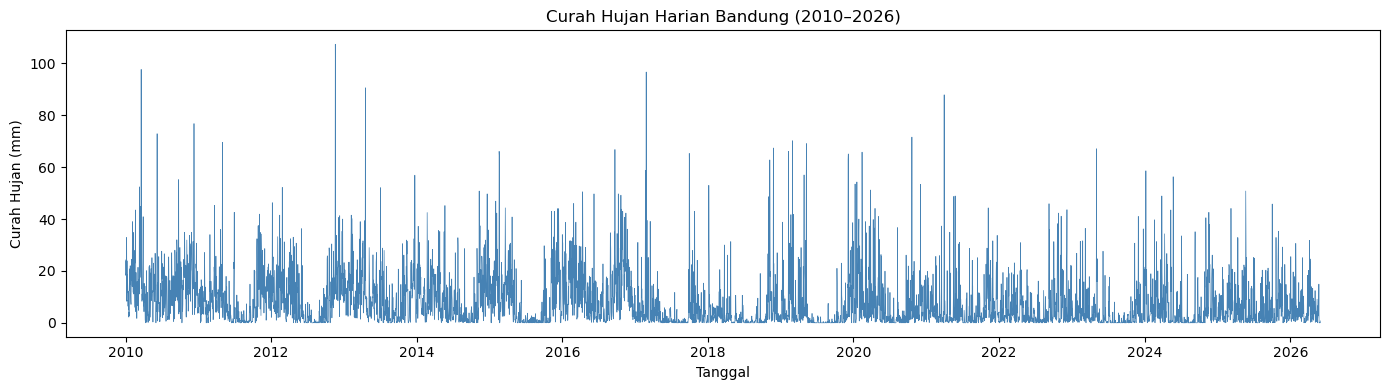

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df.index, df['precipitation_mm'], linewidth=0.5, color='steelblue')
ax.set_title('Curah Hujan Harian Bandung (2010–2026)')
ax.set_xlabel('Tanggal')
ax.set_ylabel('Curah Hujan (mm)')
plt.tight_layout()
plt.savefig('../outputs/01_raw_timeseries.png', dpi=150)
plt.show()

In [8]:
print(df['precipitation_mm'].describe())
print(f"\nHari tanpa hujan (0 mm): {(df['precipitation_mm'] == 0).sum()}")
print(f"Persentase hari kering: {(df['precipitation_mm'] == 0).mean()*100:.1f}%")
print(f"Hari hujan ringan (0.5–20 mm)   : {((df['precipitation_mm'] >= 0.5) & (df['precipitation_mm'] < 20)).sum()}")
print(f"Hari hujan sedang (20–50 mm)    : {((df['precipitation_mm'] >= 20) & (df['precipitation_mm'] < 50)).sum()}")
print(f"Hari hujan lebat (50–100 mm)    : {((df['precipitation_mm'] >= 50) & (df['precipitation_mm'] < 100)).sum()}")
print(f"Hari hujan sangat lebat (100–150 mm): {((df['precipitation_mm'] >= 100) & (df['precipitation_mm'] < 150)).sum()}")
print(f"Hari hujan ekstrem (>150)    : {(df['precipitation_mm'] > 150).sum()}")

count    5995.000000
mean        7.664971
std        10.261334
min         0.000000
25%         0.700000
50%         3.400000
75%        11.300000
max       107.400000
Name: precipitation_mm, dtype: float64

Hari tanpa hujan (0 mm): 758
Persentase hari kering: 12.6%
Hari hujan ringan (0.5–20 mm)   : 4075
Hari hujan sedang (20–50 mm)    : 625
Hari hujan lebat (50–100 mm)    : 41
Hari hujan sangat lebat (100–150 mm): 1
Hari hujan ekstrem (>150)    : 0


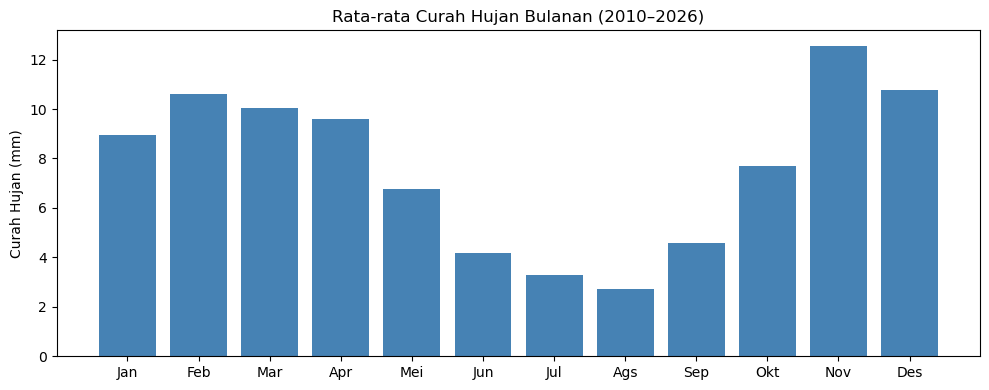

In [9]:
df['month'] = df.index.month
monthly_avg = df.groupby('month')['precipitation_mm'].mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(monthly_avg.index, monthly_avg.values, color='steelblue')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','Mei','Jun',
                    'Jul','Ags','Sep','Okt','Nov','Des'])
ax.set_title('Rata-rata Curah Hujan Bulanan (2010–2026)')
ax.set_ylabel('Curah Hujan (mm)')
plt.tight_layout()
plt.savefig('../outputs/02_monthly_avg.png', dpi=150)
plt.show()

In [11]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['precipitation_mm'], autolag='AIC')

print(f"ADF Statistic : {result[0]:.4f}")
print(f"p-value       : {result[1]:.4f}")
print(f"Lags used     : {result[2]}")
print(f"\nCritical Values:")
for key, val in result[4].items():
    print(f"  {key}: {val:.4f}")

ADF Statistic : -8.5688
p-value       : 0.0000
Lags used     : 22

Critical Values:
  1%: -3.4314
  5%: -2.8620
  10%: -2.5670


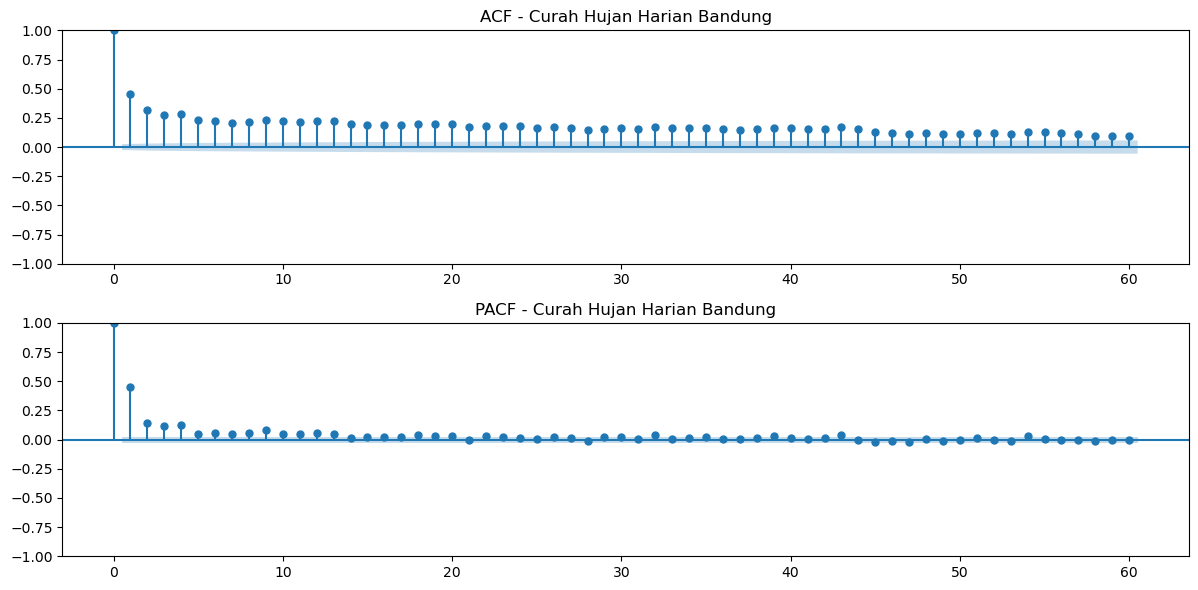

In [12]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))

plot_acf(df['precipitation_mm'], lags=60, ax=ax1)
ax1.set_title('ACF - Curah Hujan Harian Bandung')

plot_pacf(df['precipitation_mm'], lags=60, ax=ax2)
ax2.set_title('PACF - Curah Hujan Harian Bandung')

plt.tight_layout()
plt.savefig('../outputs/03_acf_pacf.png', dpi=150)
plt.show()